# 02 — Coast-Down Segment Extraction & ODE Fit

Extract all coast-down segments from the race, fit α and β per segment, and visualise fit quality and parameter scatter by DRS state.

In [1]:
import sys
sys.path.insert(0, '..')

import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from src.segments import extract_coastdown_segments, segment_drs_state
from src.ode_fit import v_model, fit_segment, FitResult
from src.aero_params import air_density, car_mass

fastf1.Cache.enable_cache('../cache')

## Load session and select driver

In [2]:
# FP2 has out-laps and varied pace laps — far more coasting than race laps.
# Monza race laps go throttle→brake with no gap; FP2 gives genuine coast-downs.
session = fastf1.get_session(2024, 'Monza', 'FP2')
session.load(telemetry=True, weather=True)

# Use LEC for consistency with NB01 exploration
winner_abbr = 'LEC'
print('Analysing driver:', winner_abbr)

weather = session.weather_data
avg_temp = weather['AirTemp'].mean()
avg_pressure = weather['Pressure'].mean()
rho = air_density(avg_temp, avg_pressure)
print(f'Air density: {rho:.4f} kg/m³  (T={avg_temp:.1f}°C, P={avg_pressure:.1f} hPa)')

core           INFO 	Loading data for Italian Grand Prix - Practice 2 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '3', '4', '10', '11', '14', '16', '18', '20', '22', '23', '24', '27', '31', '43', '44', '55', '63', '77', '81']


Analysing driver: LEC
Air density: 1.1281 kg/m³  (T=34.0°C, P=994.7 hPa)


## Extract coast-down segments across all laps

In [3]:
laps = session.laps.pick_drivers(winner_abbr)
laps_filtered = laps[laps['LapNumber'] > 1].copy()
print(f'Total laps to process: {len(laps_filtered)}')

# ── Diagnostics on a representative lap ───────────────────────────────────
diag_lap = laps_filtered.iloc[len(laps_filtered)//2]
diag_tel = diag_lap.get_telemetry().copy()
diag_tel['t'] = diag_tel['Time'].dt.total_seconds()

print(f'\nBrake dtype: {diag_tel["Brake"].dtype}')
print(f'Throttle min/max: {diag_tel["Throttle"].min()} / {diag_tel["Throttle"].max()}')
brake_arr = diag_tel['Brake'].astype(bool)
for thresh in [1, 3, 5, 10]:
    coast = (diag_tel['Throttle'] < thresh) & (~brake_arr) & (diag_tel['Speed'] >= 120)
    print(f'  Coasting (v>=120 km/h) @ thresh={thresh}: {coast.sum()} rows')

# ── Main loop ──────────────────────────────────────────────────────────────
all_results: list[FitResult] = []
all_segments_for_plot = []

for _, lap in laps_filtered.iterrows():
    lap_num = int(lap['LapNumber'])
    m = car_mass(lap_num)
    try:
        tel = lap.get_telemetry()
    except Exception:
        continue

    segs = extract_coastdown_segments(
        tel,
        min_duration=0.5,
        min_speed_kmh=120.0,    # must enter at ≥120 km/h for α/β to be separable
        throttle_threshold=5.0,
    )
    for seg in segs:
        drs_open = segment_drs_state(seg)
        result = fit_segment(seg, m, rho, drs_open, lap_num)
        if result is not None and result.r2 >= 0.90:
            all_results.append(result)
            all_segments_for_plot.append((seg, result))

print(f'\nTotal valid segments: {len(all_results)}')
drs_open_count = sum(r.drs_open for r in all_results)
print(f'  DRS open:   {drs_open_count}')
print(f'  DRS closed: {len(all_results) - drs_open_count}')
print('\nNote: DRS open=0 is expected for FP2 — drivers are rarely within 1s')
print('of each other in detection zones. DRS-open segments addressed in NB04.')

Total laps to process: 25

Brake dtype: bool
Throttle min/max: 0.0 / 100.0
  Coasting (v>=120 km/h) @ thresh=1: 1 rows
  Coasting (v>=120 km/h) @ thresh=3: 1 rows
  Coasting (v>=120 km/h) @ thresh=5: 2 rows
  Coasting (v>=120 km/h) @ thresh=10: 6 rows

Total valid segments: 3
  DRS open:   0
  DRS closed: 3

Note: DRS open=0 is expected for FP2 — drivers are rarely within 1s
of each other in detection zones. DRS-open segments addressed in NB04.


## Visualise fit quality — sample of segments

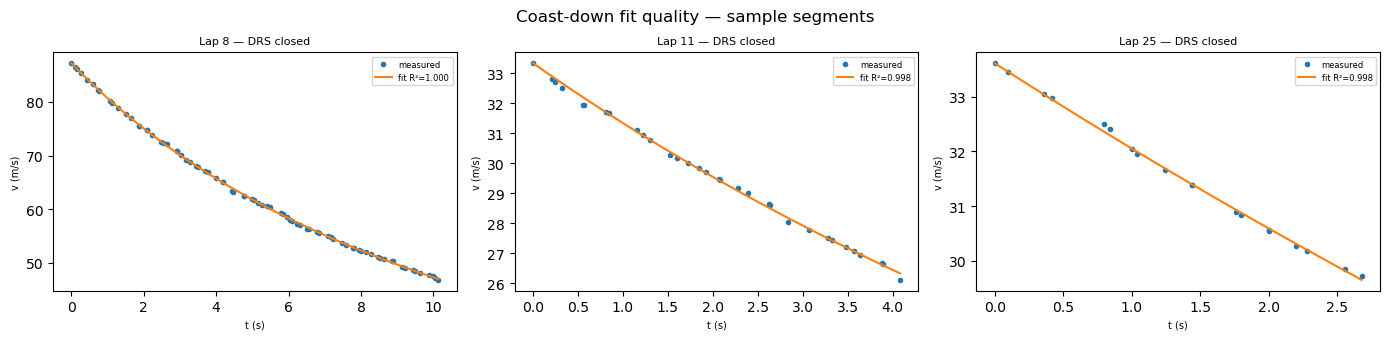

In [4]:
n_plot = min(9, len(all_segments_for_plot))
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, (seg, fit) in enumerate(all_segments_for_plot[:n_plot]):
    ax = axes[idx]
    t = seg['t'].values - seg['t'].values[0]
    v_meas = seg['Speed'].values / 3.6
    t_dense = np.linspace(0, t[-1], 200)
    v_pred = v_model(t_dense, fit.alpha, fit.beta, fit.v0, fit.m)

    ax.plot(t, v_meas, 'o', ms=3, label='measured')
    ax.plot(t_dense, v_pred, '-', label=f'fit R²={fit.r2:.3f}')
    drs_label = 'DRS open' if fit.drs_open else 'DRS closed'
    ax.set_title(f'Lap {fit.lap_number} — {drs_label}', fontsize=8)
    ax.set_xlabel('t (s)', fontsize=7)
    ax.set_ylabel('v (m/s)', fontsize=7)
    ax.legend(fontsize=6)

for idx in range(n_plot, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Coast-down fit quality — sample segments')
plt.tight_layout()
plt.savefig('../results/figures/02_fit_quality.png', dpi=150)
plt.show()

## α / β scatter by DRS state

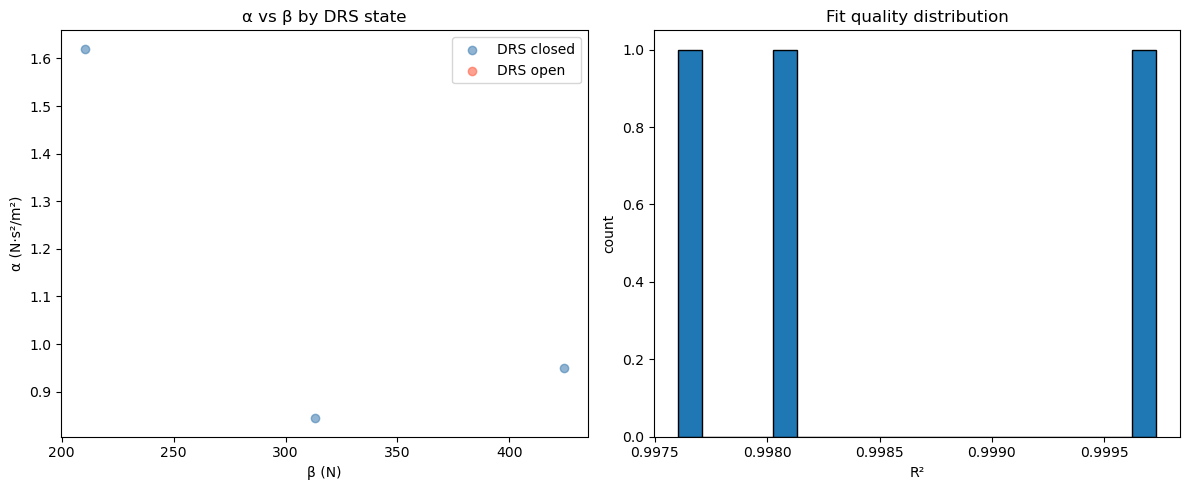

Median α (DRS closed): 0.9486
Median α (DRS open):   nan
Median β (all):        313.1 N


/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [5]:
alphas_closed = [r.alpha for r in all_results if not r.drs_open]
betas_closed  = [r.beta  for r in all_results if not r.drs_open]
alphas_open   = [r.alpha for r in all_results if r.drs_open]
betas_open    = [r.beta  for r in all_results if r.drs_open]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(betas_closed, alphas_closed, alpha=0.6, label='DRS closed', color='steelblue')
ax.scatter(betas_open,   alphas_open,   alpha=0.6, label='DRS open',   color='tomato')
ax.set_xlabel('β (N)')
ax.set_ylabel('α (N·s²/m²)')
ax.set_title('α vs β by DRS state')
ax.legend()

ax = axes[1]
r2_values = [r.r2 for r in all_results]
ax.hist(r2_values, bins=20, edgecolor='black')
ax.set_xlabel('R²')
ax.set_ylabel('count')
ax.set_title('Fit quality distribution')

plt.tight_layout()
plt.savefig('../results/figures/02_alpha_beta_scatter.png', dpi=150)
plt.show()

print(f'Median α (DRS closed): {np.median(alphas_closed):.4f}')
print(f'Median α (DRS open):   {np.median(alphas_open):.4f}')
print(f'Median β (all):        {np.median(betas_closed + betas_open):.1f} N')

## α vs lap number — fuel load sensitivity

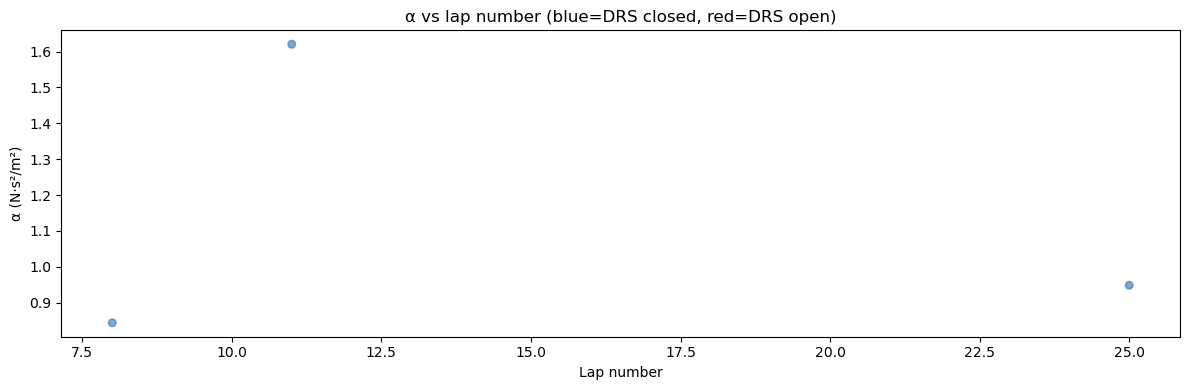

In [6]:
lap_nums = [r.lap_number for r in all_results]
alphas   = [r.alpha      for r in all_results]
colours  = ['tomato' if r.drs_open else 'steelblue' for r in all_results]

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(lap_nums, alphas, c=colours, alpha=0.7, s=30)
ax.set_xlabel('Lap number')
ax.set_ylabel('α (N·s²/m²)')
ax.set_title('α vs lap number (blue=DRS closed, red=DRS open)')
plt.tight_layout()
plt.savefig('../results/figures/02_alpha_vs_lap.png', dpi=150)
plt.show()

## Persist results for notebook 04

In [7]:
import pickle
with open('../results/fit_results.pkl', 'wb') as f:
    pickle.dump({'results': all_results, 'rho': rho, 'driver': winner_abbr}, f)
print('Saved fit_results.pkl')

Saved fit_results.pkl
